In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Preparação dos dados

In [2]:
#Carregar os dados
dataset = pd.read_csv(r'C:\Users\mateu\OneDrive\Documentos\SPTECH\TCC\backend\tabela_final\part-00000-bc8041e1-56a7-4223-b839-8474dfbae85d-c000.csv')

# Prepara a coluna de datas para o split temporal ANTES de apagá-la do dataset principal
# Treino: ate Junho de 2018 | Teste: Julho de 2018 em diante.
split_date = pd.to_datetime('2018-07-01', utc=True)
date_col = pd.to_datetime(dataset['order_delivered_carrier_date'], utc=True)


# Remover colunas conforme solicitado (clima e vazamento de dados)
colunas_remover = [
    # Vazamento de dados / Pós-compra (ocorrem após aprovação ou derivam do tempo de entrega)
    'order_delivered_customer_date', 
    'order_delivered_carrier_date',
    'review_score', 
    # 'delivered_on_time', # Vamos manter esta no df principal apenas para análises descritivas, não passaremos ela para 'X'.
    'approval_time_hours', 
    'handling_time_hours', 
    'shipping_delay_hours',
    
    # Variáveis climáticas (Vendedor)
    'seller_total_rainfall_period_mm',
    'seller_max_rain_intensity_mm_h',
    'seller_max_wind_gust_period_ms',
    'seller_interval_code',
    'seller_rain_class_code',
    'seller_wind_class_code',
    'seller_accumulated_rainfall_3_days_mm',
    'seller_is_heavy_rain',
    'seller_is_strong_wind',
    
    # Variáveis climáticas (Cliente)
    'customer_total_rainfall_period_mm',
    'customer_max_rain_intensity_mm_h',
    'customer_max_wind_gust_period_ms',
    'customer_interval_code',
    'customer_rain_class_code',
    'customer_wind_class_code',
    'customer_accumulated_rainfall_3_days_mm',
    'customer_is_heavy_rain',
    'customer_is_strong_wind',

    'seller_meso_metropolitana_de_sao_paulo',
    'seller_meso_araraquara',
    'seller_meso_piracicaba',
    'seller_meso_ribeirao_preto',
    'seller_meso_sao_jose_do_rio_preto',
    'seller_meso_campinas',
    'seller_meso_vale_do_paraiba_paulista',
    'seller_meso_macro_metropolitana_paulista',
    'seller_meso_bauru',
    'seller_meso_presidente_prudente',
    'seller_meso_marilia',
    'seller_meso_assis',
    'seller_meso_aracatuba',
    'seller_meso_litoral_sul_paulista',
    'seller_meso_itapetininga',
    'customer_meso_metropolitana_de_sao_paulo',
    'customer_meso_piracicaba',
    'customer_meso_campinas',
    'customer_meso_vale_do_paraiba_paulista',
    'customer_meso_ribeirao_preto',
    'customer_meso_sao_jose_do_rio_preto',
    'customer_meso_macro_metropolitana_paulista',
    'customer_meso_bauru','customer_meso_araraquara',
    'customer_meso_presidente_prudente',
    'customer_meso_marilia',
    'customer_meso_assis',
    'customer_meso_aracatuba',
    'customer_meso_itapetininga',
    'customer_meso_litoral_sul_paulista'
]

df = dataset.drop(columns=colunas_remover)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 33820 entries, 0 to 33819
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   holiday_at_shipping       33820 non-null  int64  
 1   delivery_time_days        33820 non-null  float64
 2   purchase_hour             33820 non-null  int64  
 3   purchase_day_of_week      33820 non-null  int64  
 4   is_weekend                33820 non-null  int64  
 5   price                     33820 non-null  float64
 6   freight_value             33820 non-null  float64
 7   product_weight_g          33820 non-null  int64  
 8   volume_cm3                33820 non-null  float64
 9   distance_km               33820 non-null  float64
 10  same_city                 33820 non-null  int64  
 11  delivered_on_time         33820 non-null  int64  
 12  seller_geolocation_lat    33820 non-null  float64
 13  seller_geolocation_lng    33820 non-null  float64
 14  customer_geolocat

In [4]:
# Separar features (X) e target (y)
X = df.drop(columns=["delivered_on_time"])
y = df["delivered_on_time"]

### Divisão de treino e teste

In [5]:
# Split temporal
# Criar máscaras booleanas para treino e teste com base na coluna de datas
train_mask = date_col.loc[X.index] < split_date
test_mask = date_col.loc[X.index] >= split_date

# Criar os conjuntos de treino e teste usando as máscaras
X_train = X[train_mask].copy()
y_train = y[train_mask].copy()
X_test = X[test_mask].copy()
y_test = y[test_mask].copy()
print(f"Treino: {len(X_train)} amostras | Teste: {len(X_test)} amostras")

Treino: 28706 amostras | Teste: 5114 amostras


In [6]:
# Análise descritiva do split
n_total = len(X)
n_train = int(train_mask.sum())
n_test = int(test_mask.sum())

# Contagem de atrasos (classe 0) em cada particao
n_train_atraso = int(y[train_mask].eq(0).sum())
n_test_atraso = int(y[test_mask].eq(0).sum())

# Calcular porcentagens de atrasos em cada particao
train_atraso_pct = f"{n_train_atraso / n_train:.2%}" if n_train else "0.00%"
test_atraso_pct = f"{n_test_atraso / n_test:.2%}" if n_test else "0.00%"

print(f"Total de registros: {n_total}\n")
print(f"Treino (até Jun/2018): {n_train} ({n_train/n_total:.2%})")
print(f" - Atrasos no Treino: {n_train_atraso} ({train_atraso_pct} do treino)\n")
print(f"Teste (Jul/2018 em diante): {n_test} ({n_test/n_total:.2%})")
print(f" - Atrasos no Teste: {n_test_atraso} ({test_atraso_pct} do teste)\n")

Total de registros: 33820

Treino (até Jun/2018): 28706 (84.88%)
 - Atrasos no Treino: 1425 (4.96% do treino)

Teste (Jul/2018 em diante): 5114 (15.12%)
 - Atrasos no Teste: 613 (11.99% do teste)



In [7]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(random_state=42)
classifier.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [8]:
novo = X_test.iloc[[0]]
print(classifier.predict(novo))

[1]


In [9]:
y_pred = classifier.predict(X_test)

# Matriz de Confusão

In [10]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(recall_score(y_test, y_pred))


[[  69  544]
 [  37 4464]]
0.8863903011341415
0.8913738019169329
0.9917796045323262


Propriedades do Classificador

In [11]:
print(classifier.predict_proba(novo))
print(classifier.classes_)
print(classifier.max_features_)
print(classifier.feature_importances_)
print(classifier.n_features_in_)

[[0. 1.]]
[0 1]
16
[0.00069838 0.54737172 0.03279438 0.02285448 0.00334948 0.05112823
 0.09307873 0.04481433 0.03968311 0.05994879 0.00408101 0.01444523
 0.01089205 0.01374722 0.01853554 0.04257734]
16


Visualizar dados de treinamento

 



c:\Users\mateu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


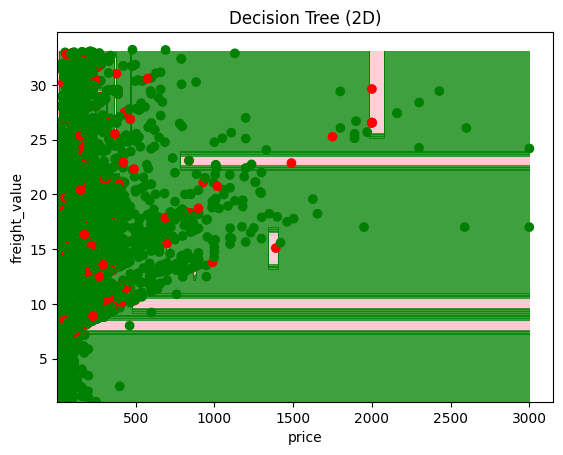

In [12]:
X_2d = dataset[["price", "freight_value"]]
y = dataset["delivered_on_time"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_2d, y, test_size=0.2, random_state=42)

from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(random_state=42)
classifier.fit(X_train, y_train)

X_set = X_train.values
y_set = y_train.values

from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min(), stop=X_set[:, 0].max(), step=1),
    np.arange(start=X_set[:, 1].min(), stop=X_set[:, 1].max(), step=1)
)

plt.contourf(
    X1, X2,
    classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.75,
    cmap=ListedColormap(('pink', 'green'))
)

plt.scatter(X_set[:, 0], X_set[:, 1], c=y_set, cmap=ListedColormap(('red', 'green')))
plt.xlabel("price")
plt.ylabel("freight_value")
plt.title("Decision Tree (2D)")
plt.show()

Visualizar dados de teste

c:\Users\mateu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\mateu\AppData\Local\Temp\ipykernel_20284\1824099838.py:34: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


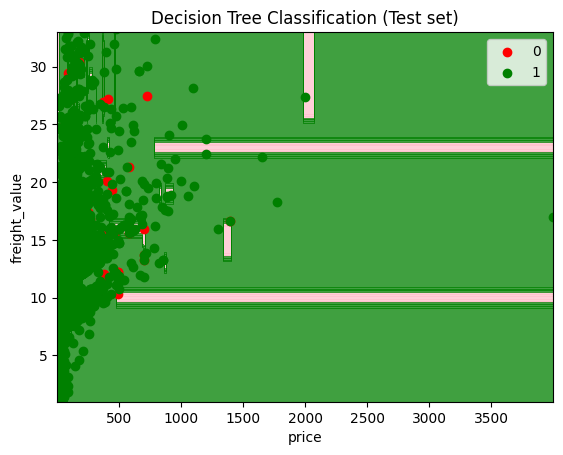

In [13]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import numpy as np

X_2d = dataset[["price", "freight_value"]]
y = dataset["delivered_on_time"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_2d, y, test_size=0.2, random_state=42)

from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(random_state=42)
classifier.fit(X_train, y_train)

X_set = X_test.values
y_set = y_test.values

X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min(), stop=X_set[:, 0].max(), step=1),
    np.arange(start=X_set[:, 1].min(), stop=X_set[:, 1].max(), step=1)
)

plt.contourf(
    X1, X2,
    classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.75,
    cmap=ListedColormap(('pink', 'green'))
)

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0],
        X_set[y_set == j, 1],
        c=ListedColormap(('red', 'green'))(i),
        label=j
    )

plt.title('Decision Tree Classification (Test set)')
plt.xlabel('price')
plt.ylabel('freight_value')
plt.legend()
plt.show()

## Visualizar Matriz de Confusão e Árvore de Decisão

<Figure size 600x500 with 0 Axes>

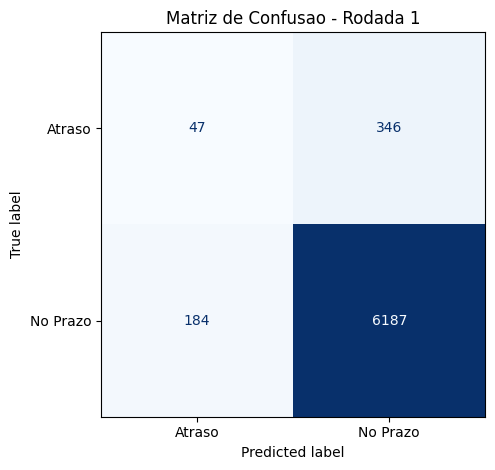

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Predicoes no conjunto de teste para a matriz de confusao
y_pred_tree = classifier.predict(X_test)
cm_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=["Atraso", "No Prazo"]).plot(cmap="Blues", colorbar=False)
plt.title("Matriz de Confusao - Rodada 1")
plt.tight_layout()
plt.show()

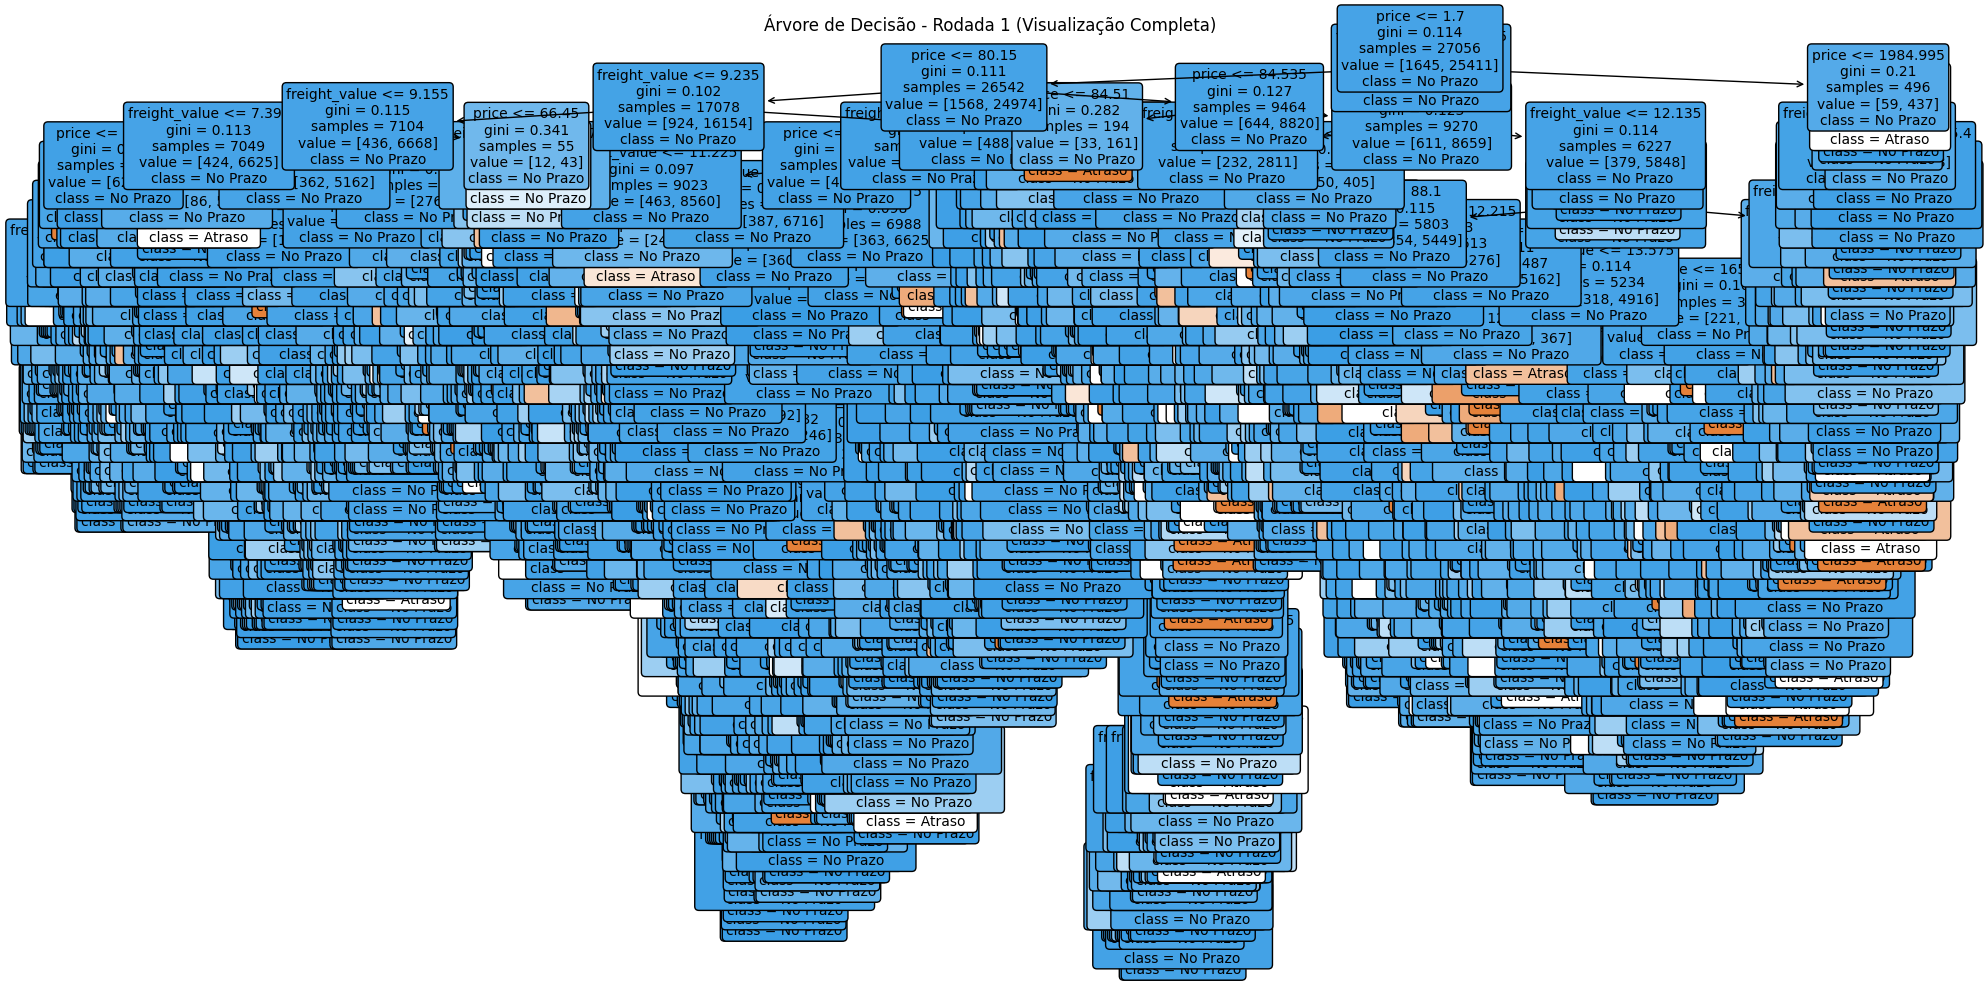

In [15]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(
    classifier, 
    feature_names=["price", "freight_value"], 
    class_names=["Atraso", "No Prazo"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Árvore de Decisão - Rodada 1 (Visualização Completa)")
plt.tight_layout()
plt.show()

## Modelo Melhorado

Versao robusta com:
- split temporal reaproveitado (sem novo sorteio)
- tratamento de nulos e variaveis categoricas via pipeline
- busca de hiperparametros com GridSearchCV
- metricas completas no teste e em validacao cruzada

MELHOR CONFIGURACAO ENCONTRADA (GRID SEARCH)
Hiperparametros:
{'model__ccp_alpha': 0.0, 'model__criterion': 'entropy', 'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
Melhor F1 (CV): 0.8450

DESEMPENHO NO CONJUNTO DE TESTE
Accuracy             : 0.7914
Precision (weighted) : 0.9019
Recall (weighted)    : 0.7914
F1 (weighted)        : 0.8387

Relatorio por classe:
              precision    recall  f1-score   support

           0       0.10      0.32      0.15       393
           1       0.95      0.82      0.88      6371

    accuracy                           0.79      6764
   macro avg       0.53      0.57      0.52      6764
weighted avg       0.90      0.79      0.84      6764



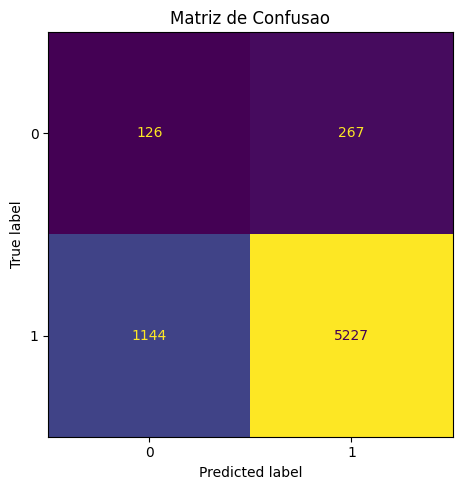

METRICAS DE PROBABILIDADE (BINARIO)
ROC-AUC: 0.5704
PR-AUC : 0.9496

ESTABILIDADE EM VALIDACAO CRUZADA (TREINO)
accuracy             -> media: 0.8028 | desvio: 0.0032
precision_weighted   -> media: 0.9021 | desvio: 0.0007
recall_weighted      -> media: 0.8028 | desvio: 0.0032
f1_weighted          -> media: 0.8450 | desvio: 0.0021

TOP 15 FEATURES MAIS IMPORTANTES
           feature  importance
        num__price    0.593392
num__freight_value    0.406608


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
 )
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

# 1) Validacoes basicas
if "delivered_on_time" not in df.columns:
    raise ValueError("A coluna alvo 'delivered_on_time' nao foi encontrada no dataset.")
if y_train.nunique() < 2:
    raise ValueError("A coluna alvo precisa ter pelo menos duas classes para classificacao.")

# 2) Pipeline de preprocessamento + modelo (reaproveita split temporal)
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                random_state=42,
                class_weight="balanced",
            ),
        ),
    ]
)

param_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [3, 5, 8, 12, None],
    "model__min_samples_split": [2, 10, 30],
    "model__min_samples_leaf": [1, 5, 10],
    "model__ccp_alpha": [0.0, 0.001, 0.01],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1,
    refit=True,
 )

grid.fit(X_train, y_train)
best_model = grid.best_estimator_

print("=" * 70)
print("MELHOR CONFIGURACAO ENCONTRADA (GRID SEARCH)")
print("=" * 70)
print("Hiperparametros:")
print(grid.best_params_)
print(f"Melhor F1 (CV): {grid.best_score_:.4f}")

# 3) Avaliacao no conjunto de teste (split temporal)
y_pred = best_model.predict(X_test)

print("\n" + "=" * 70)
print("DESEMPENHO NO CONJUNTO DE TESTE")
print("=" * 70)
print(f"Accuracy             : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision (weighted) : {precision_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
print(f"Recall (weighted)    : {recall_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
print(f"F1 (weighted)        : {f1_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")

print("\nRelatorio por classe:")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=ax, colorbar=False)
ax.set_title("Matriz de Confusao")
plt.tight_layout()
plt.show()

# 4) ROC-AUC e PR-AUC para classificacao binaria
if y_train.nunique() == 2 and hasattr(best_model, "predict_proba"):
    y_proba = best_model.predict_proba(X_test)[:, 1]
    print("=" * 70)
    print("METRICAS DE PROBABILIDADE (BINARIO)")
    print("=" * 70)
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
    print(f"PR-AUC : {average_precision_score(y_test, y_proba):.4f}")

# 5) Estabilidade das metricas via validacao cruzada
cv_scores = cross_validate(
    best_model,
    X_train,
    y_train,
    cv=cv,
    scoring=["accuracy", "precision_weighted", "recall_weighted", "f1_weighted"],
    n_jobs=-1,
)

print("\n" + "=" * 70)
print("ESTABILIDADE EM VALIDACAO CRUZADA (TREINO)")
print("=" * 70)
for metric in ["accuracy", "precision_weighted", "recall_weighted", "f1_weighted"]:
    values = cv_scores[f"test_{metric}"]
    print(f"{metric:<20} -> media: {values.mean():.4f} | desvio: {values.std():.4f}")

# 6) Top importancias das features (apos preprocessamento)
feature_names = best_model.named_steps["preprocess"].get_feature_names_out()
importances = best_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": importances,
    }
).sort_values("importance", ascending=False)

print("\n" + "=" * 70)
print("TOP 15 FEATURES MAIS IMPORTANTES")
print("=" * 70)
print(importance_df.head(15).to_string(index=False))

In [17]:
from sklearn.metrics import accuracy_score, f1_score

# Diagnostico rapido de overfitting
train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)
train_f1 = f1_score(y_train, train_pred, average="weighted", zero_division=0)
test_f1 = f1_score(y_test, test_pred, average="weighted", zero_division=0)

print("=" * 70)
print("DIAGNOSTICO DE OVERFITTING")
print("=" * 70)
print(f"Accuracy treino: {train_acc:.4f}")
print(f"Accuracy teste : {test_acc:.4f}")
print(f"Gap accuracy   : {(train_acc - test_acc):.4f}")
print()
print(f"F1 treino      : {train_f1:.4f}")
print(f"F1 teste       : {test_f1:.4f}")
print(f"Gap F1         : {(train_f1 - test_f1):.4f}")

DIAGNOSTICO DE OVERFITTING
Accuracy treino: 0.8625
Accuracy teste : 0.7914
Gap accuracy   : 0.0711

F1 treino      : 0.8930
F1 teste       : 0.8387
Gap F1         : 0.0543


## Visualizar Árvore do Modelo Melhorado

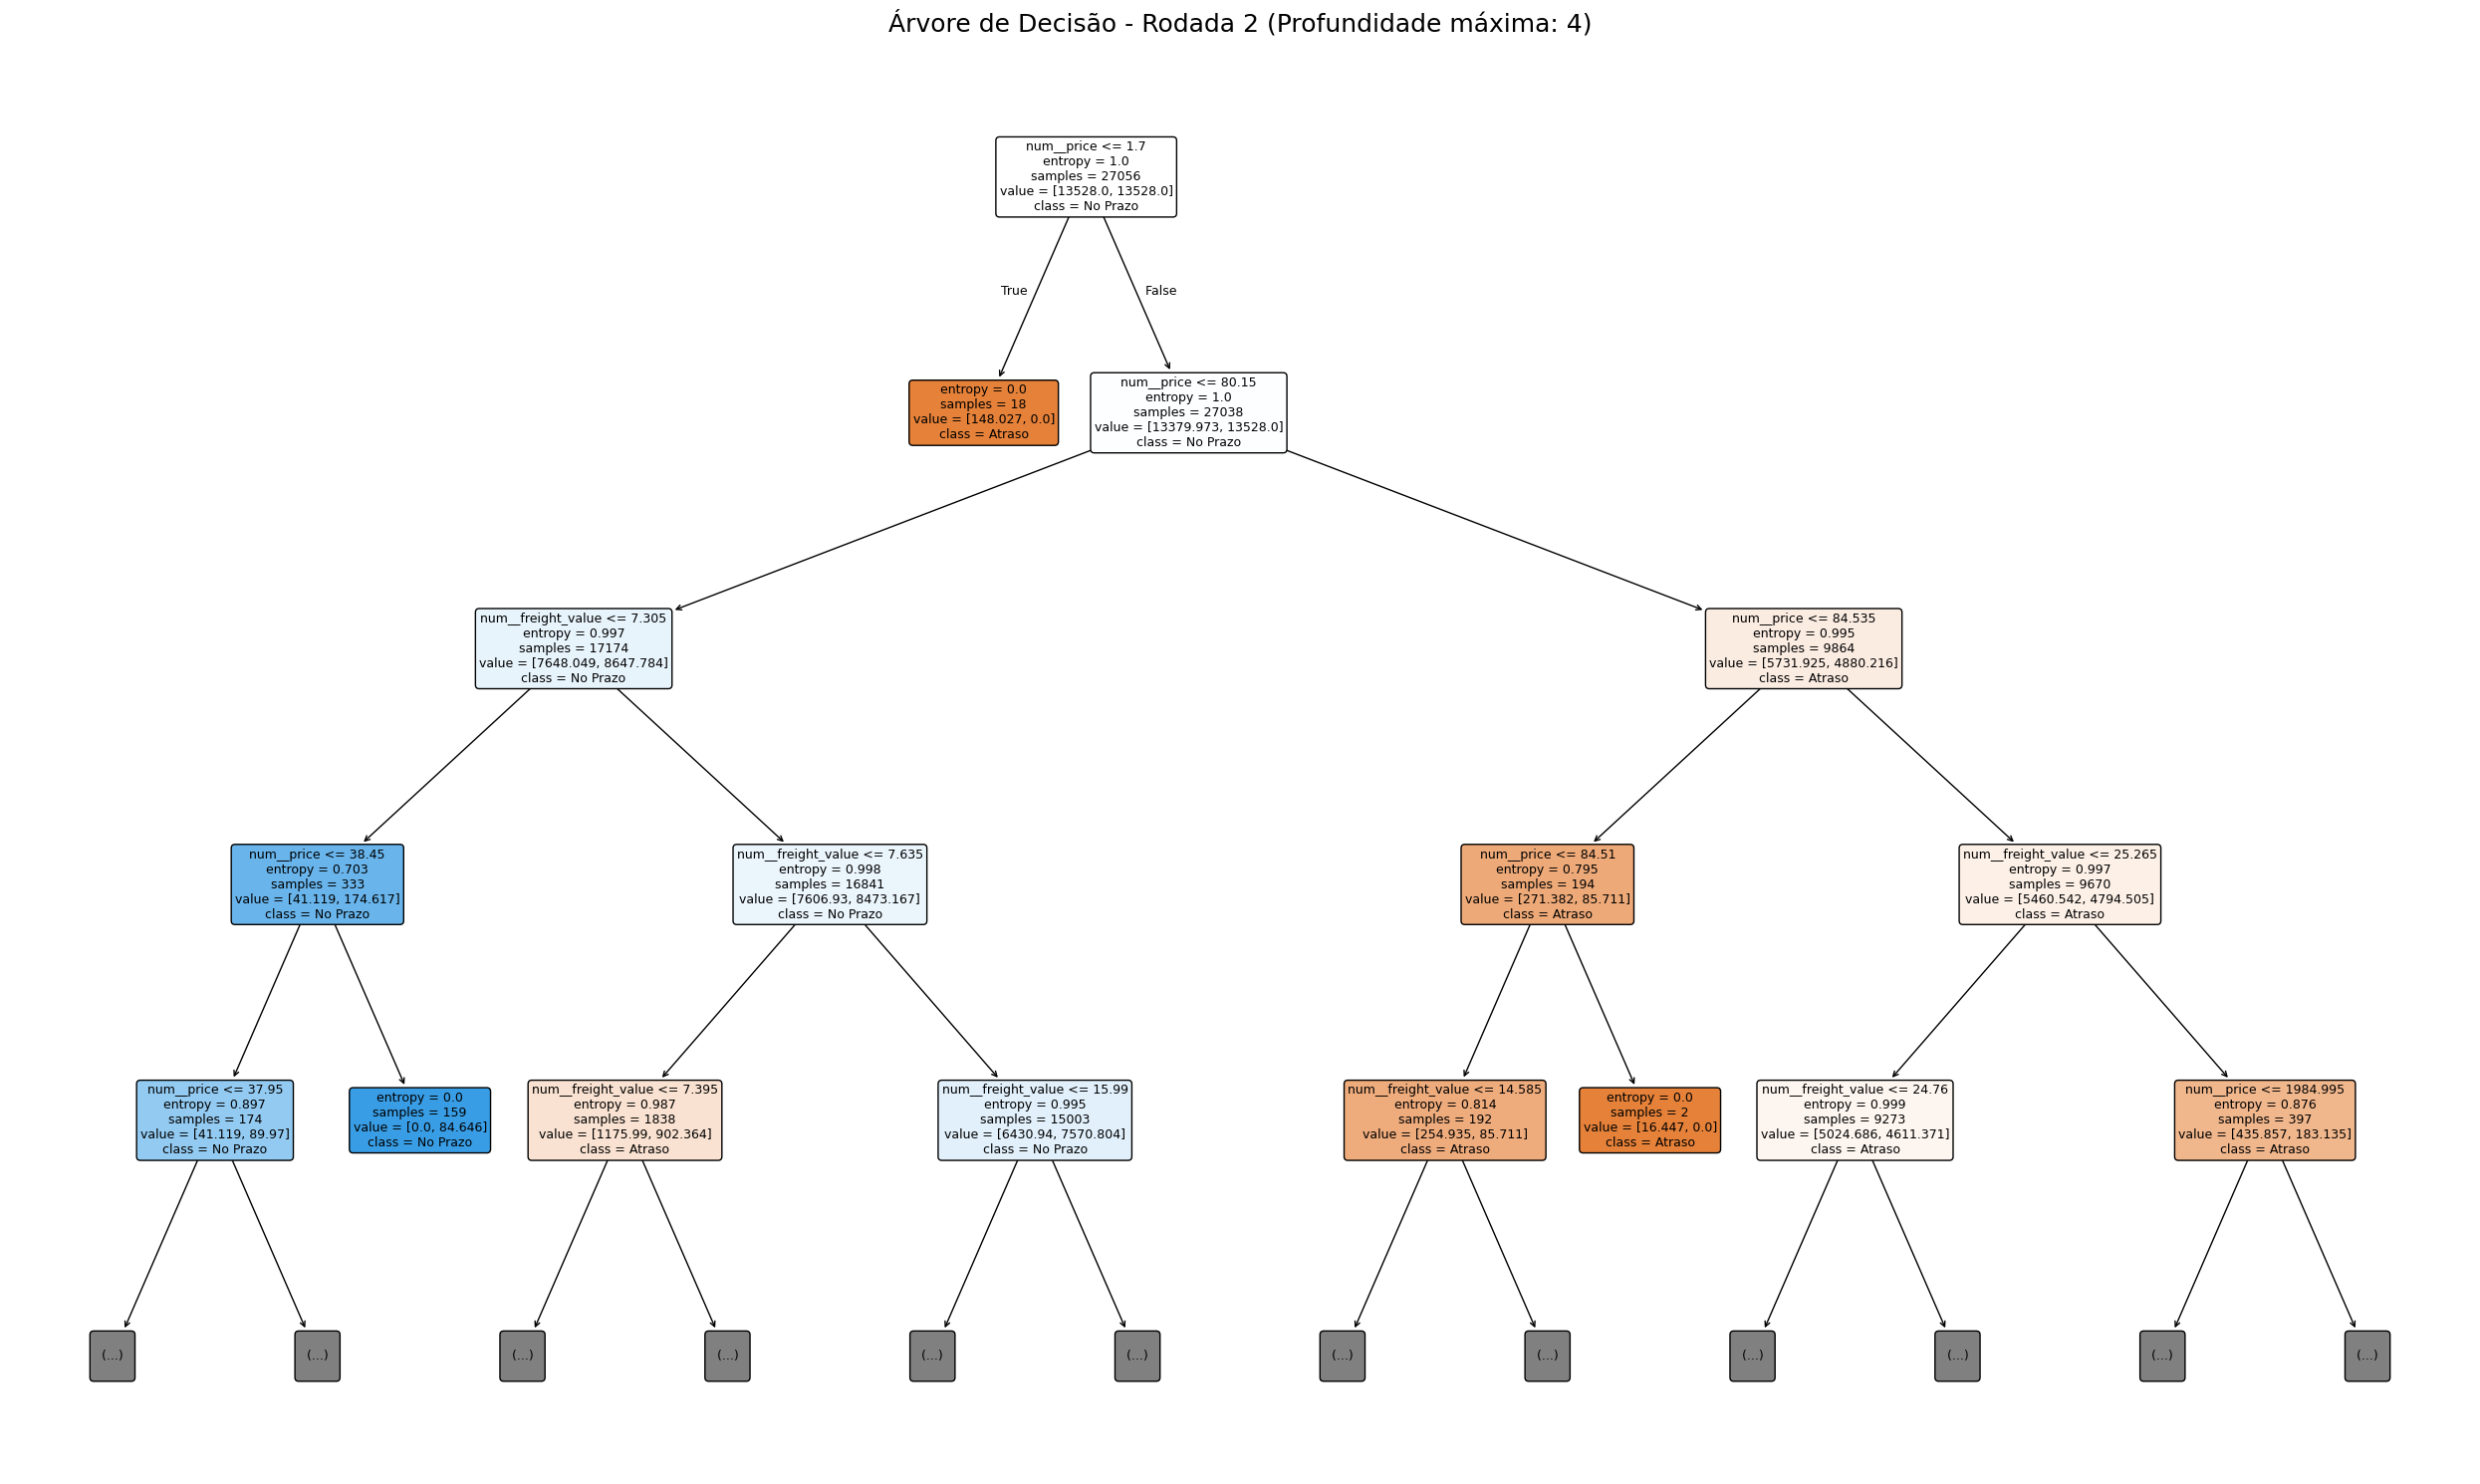

Profundidade da árvore completa: 61
Número total de nós: 5677
Número de features usadas: 2


In [18]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Extrai o modelo de decision tree do pipeline
tree_model = best_model.named_steps["model"]

# Obtém os nomes das features após o preprocessamento
feature_names = best_model.named_steps["preprocess"].get_feature_names_out().tolist()

# Limita a profundidade da visualização para melhor legibilidade
plt.figure(figsize=(25, 15))
plot_tree(
    tree_model, 
    feature_names=feature_names, 
    class_names=["Atraso", "No Prazo"],
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=4  # Mostra até 4 níveis de profundidade
)
plt.title("Árvore de Decisão - Rodada 2 (Profundidade máxima: 4)", fontsize=18, pad=20)
plt.tight_layout()
plt.show()

print(f"Profundidade da árvore completa: {tree_model.get_depth()}")
print(f"Número total de nós: {tree_model.tree_.node_count}")
print(f"Número de features usadas: {tree_model.n_features_in_}")

## Rodada 2: Reducao de Overfitting e Foco na Classe 0

Nesta etapa:
- restringimos a complexidade da arvore (poda e limites)
- otimizamos por `f1_macro` (mais justo para classes desbalanceadas)
- ajustamos o limiar de decisao para melhorar a classe 0

In [24]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, f1_score, recall_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Reaproveita o split temporal
X_train_full = X_train
y_train_full = y_train
X_test_full = X_test
y_test_full = y_test

# Separa validacao interna para ajuste do limiar sem usar o teste final
X_train_inner, X_val, y_train_inner, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full,
 )

num_cols = X_train_inner.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train_inner.select_dtypes(exclude=[np.number]).columns.tolist()

preprocessor_v2 = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]), num_cols),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            cat_cols,
        ),
    ]
)

pipeline_v2 = Pipeline(
    steps=[
        ("preprocess", preprocessor_v2),
        (
            "model",
            DecisionTreeClassifier(
                random_state=42,
                class_weight="balanced",
            ),
        ),
    ]
)

# Grade menos restritiva para permitir arvores mais profundas
param_grid_v2 = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [4, 6, 8, 12, 16, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__ccp_alpha": [0.0, 0.001, 0.005],
}

cv_v2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_v2 = GridSearchCV(
    estimator=pipeline_v2,
    param_grid=param_grid_v2,
    cv=cv_v2,
    scoring="f1_macro",
    n_jobs=-1,
    refit=True,
 )

grid_v2.fit(X_train_inner, y_train_inner)
best_model_v2 = grid_v2.best_estimator_

print("=" * 70)
print("RODADA 2 - MELHOR MODELO (FOCO EM F1 MACRO)")
print("=" * 70)
print("Hiperparametros:")
print(grid_v2.best_params_)
print(f"Melhor F1 macro (CV): {grid_v2.best_score_:.4f}")

# Avaliacao com limiar padrao (0.5)
y_train_pred_default = best_model_v2.predict(X_train_full)
y_test_pred_default = best_model_v2.predict(X_test_full)

train_f1_default = f1_score(y_train_full, y_train_pred_default, average="macro", zero_division=0)
test_f1_default = f1_score(y_test_full, y_test_pred_default, average="macro", zero_division=0)

print("\n" + "=" * 70)
print("LIMIAR PADRAO (0.5)")
print("=" * 70)
print(f"F1 macro treino: {train_f1_default:.4f}")
print(f"F1 macro teste : {test_f1_default:.4f}")
print(f"Gap F1 macro   : {(train_f1_default - test_f1_default):.4f}")
print(f"Recall classe 0 (teste): {recall_score(y_test_full, y_test_pred_default, pos_label=0):.4f}")
print("\nRelatorio (teste, limiar padrao):")
print(classification_report(y_test_full, y_test_pred_default, zero_division=0))

# Ajuste de limiar usando validacao interna (sem tocar no teste)
classes_order = best_model_v2.classes_
if 1 in classes_order:
    idx_pos = int(np.where(classes_order == 1)[0][0])
else:
    idx_pos = 1

val_proba_pos = best_model_v2.predict_proba(X_val)[:, idx_pos]

best_threshold = 0.5
best_score = -1.0
for t in np.arange(0.20, 0.81, 0.02):
    pred_val = (val_proba_pos >= t).astype(int)
    score = f1_score(y_val, pred_val, average="macro", zero_division=0)
    if score > best_score:
        best_score = score
        best_threshold = float(t)

# Aplica limiar ajustado no teste final
test_proba_pos = best_model_v2.predict_proba(X_test_full)[:, idx_pos]
y_test_pred_tuned = (test_proba_pos >= best_threshold).astype(int)

print("\n" + "=" * 70)
print("LIMIAR AJUSTADO")
print("=" * 70)
print(f"Melhor limiar (validacao): {best_threshold:.2f}")
print(f"F1 macro no teste        : {f1_score(y_test_full, y_test_pred_tuned, average='macro', zero_division=0):.4f}")
print(f"Recall classe 0 (teste)  : {recall_score(y_test_full, y_test_pred_tuned, pos_label=0):.4f}")
print("\nRelatorio (teste, limiar ajustado):")
print(classification_report(y_test_full, y_test_pred_tuned, zero_division=0))

RODADA 2 - MELHOR MODELO (FOCO EM F1 MACRO)
Hiperparametros:
{'model__ccp_alpha': 0.0, 'model__criterion': 'gini', 'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
Melhor F1 macro (CV): 0.5405

LIMIAR PADRAO (0.5)
F1 macro treino: 0.6666
F1 macro teste : 0.5174
Gap F1 macro   : 0.1491
Recall classe 0 (teste): 0.3053

Relatorio (teste, limiar padrao):
              precision    recall  f1-score   support

           0       0.10      0.31      0.15       393
           1       0.95      0.83      0.89      6371

    accuracy                           0.80      6764
   macro avg       0.52      0.57      0.52      6764
weighted avg       0.90      0.80      0.84      6764


LIMIAR AJUSTADO
Melhor limiar (validacao): 0.20
F1 macro no teste        : 0.5590
Recall classe 0 (teste)  : 0.2163

Relatorio (teste, limiar ajustado):
              precision    recall  f1-score   support

           0       0.15      0.22      0.18       393
           1       

## Visualizar Árvore da Rodada 2

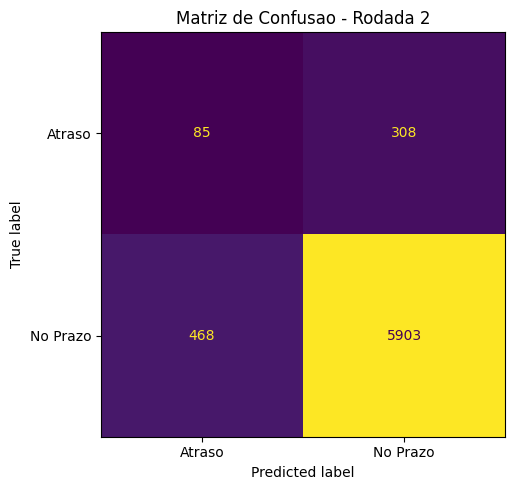

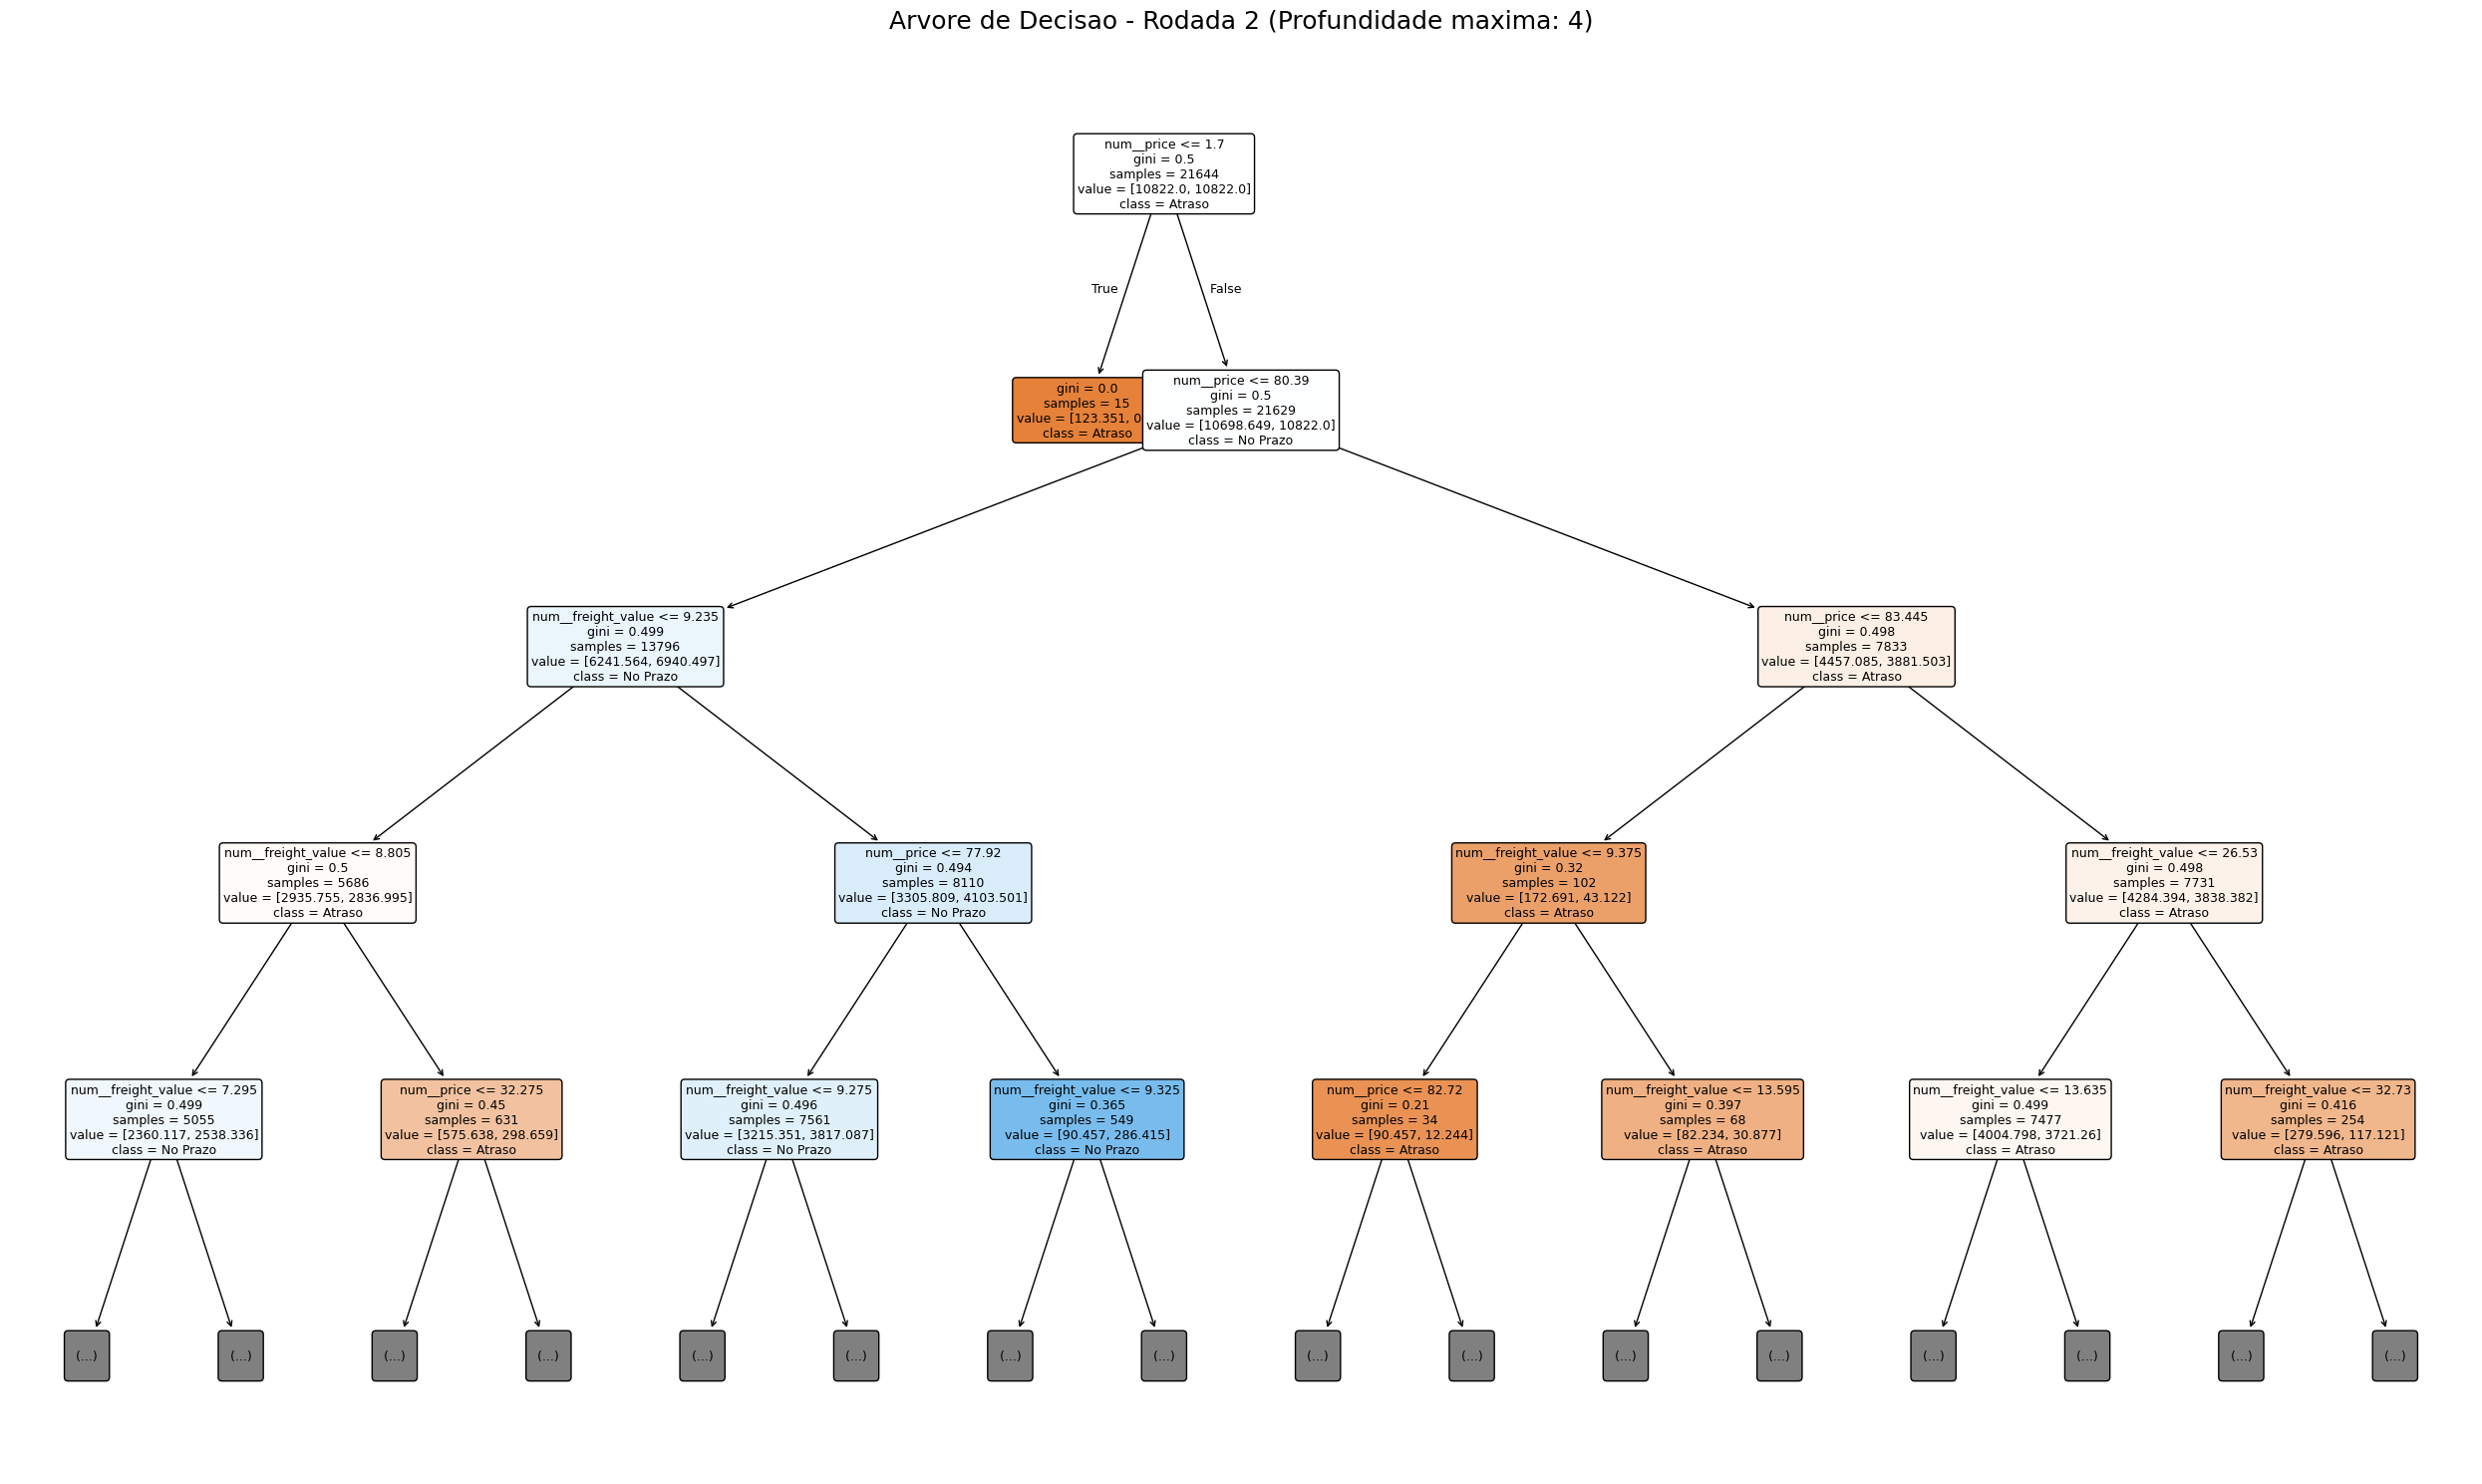

Profundidade da arvore completa: 43
Numero total de nos: 4697
Numero de features usadas: 2

Hiperparametros da arvore:
  - max_depth: None
  - min_samples_split: 2
  - min_samples_leaf: 1
  - criterion: gini


In [25]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Extrai o modelo de decision tree do pipeline da Rodada 2
tree_model_v2 = best_model_v2.named_steps["model"]

# Obtém os nomes das features após o preprocessamento
feature_names_v2 = best_model_v2.named_steps["preprocess"].get_feature_names_out().tolist()

# Matriz de confusao da Rodada 2 (nao normalizada)
cm_v2 = confusion_matrix(y_test_full, y_test_pred_tuned)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm_v2, display_labels=["Atraso", "No Prazo"]).plot(ax=ax, colorbar=False)
ax.set_title("Matriz de Confusao - Rodada 2")
plt.tight_layout()
plt.show()

# Limita a profundidade da visualização para melhor legibilidade
plt.figure(figsize=(25, 15))
plot_tree(
    tree_model_v2,
    feature_names=feature_names_v2,
    class_names=["Atraso", "No Prazo"],
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=4  # Mostra ate 4 niveis de profundidade
)
plt.title("Arvore de Decisao - Rodada 2 (Profundidade maxima: 4)", fontsize=18, pad=20)
plt.tight_layout()
plt.show()

print(f"Profundidade da arvore completa: {tree_model_v2.get_depth()}")
print(f"Numero total de nos: {tree_model_v2.tree_.node_count}")
print(f"Numero de features usadas: {tree_model_v2.n_features_in_}")
print(f"\nHiperparametros da arvore:")
print(f"  - max_depth: {tree_model_v2.max_depth}")
print(f"  - min_samples_split: {tree_model_v2.min_samples_split}")
print(f"  - min_samples_leaf: {tree_model_v2.min_samples_leaf}")
print(f"  - criterion: {tree_model_v2.criterion}")

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("=" * 90)
print("METRICAS SEPARADAS - RELATORIO")
print("=" * 90)
print("LEGENDA:")
print("- Accuracy: proporcao total de acertos")
print("- Precision: entre o que o modelo previu como uma classe, quanto estava correto")
print("- Recall: entre o que realmente era da classe, quanto o modelo encontrou")
print("- F1-score: equilibrio entre precision e recall")
print("- Macro: media simples entre as classes (mesmo peso)")
print("- Weighted: media ponderada pela quantidade de exemplos por classe")

# --- Limiar padrao (0.5) ---
acc_default = accuracy_score(y_test_full, y_test_pred_default)
prec_default_macro = precision_score(y_test_full, y_test_pred_default, average="macro", zero_division=0)
rec_default_macro = recall_score(y_test_full, y_test_pred_default, average="macro", zero_division=0)
f1_default_macro = f1_score(y_test_full, y_test_pred_default, average="macro", zero_division=0)

prec_default_weighted = precision_score(y_test_full, y_test_pred_default, average="weighted", zero_division=0)
rec_default_weighted = recall_score(y_test_full, y_test_pred_default, average="weighted", zero_division=0)
f1_default_weighted = f1_score(y_test_full, y_test_pred_default, average="weighted", zero_division=0)

prec_default_c0 = precision_score(y_test_full, y_test_pred_default, pos_label=0, zero_division=0)
rec_default_c0 = recall_score(y_test_full, y_test_pred_default, pos_label=0, zero_division=0)
f1_default_c0 = f1_score(y_test_full, y_test_pred_default, pos_label=0, zero_division=0)

prec_default_c1 = precision_score(y_test_full, y_test_pred_default, pos_label=1, zero_division=0)
rec_default_c1 = recall_score(y_test_full, y_test_pred_default, pos_label=1, zero_division=0)
f1_default_c1 = f1_score(y_test_full, y_test_pred_default, pos_label=1, zero_division=0)

print("\n" + "=" * 90)
print("[LIMIAR PADRAO 0.5]")
print("=" * 90)
print(f"Accuracy (acerto geral)                               : {acc_default:.4f}")
print(f"Precision macro (peso igual entre classes)            : {prec_default_macro:.4f}")
print(f"Recall macro (peso igual entre classes)               : {rec_default_macro:.4f}")
print(f"F1 macro (equilibrio geral entre classes)             : {f1_default_macro:.4f}")
print(f"Precision weighted (ponderado pelo tamanho da classe) : {prec_default_weighted:.4f}")
print(f"Recall weighted (ponderado pelo tamanho da classe)    : {rec_default_weighted:.4f}")
print(f"F1 weighted (ponderado pelo tamanho da classe)        : {f1_default_weighted:.4f}")
print(f"Precision classe 0                                    : {prec_default_c0:.4f}")
print(f"Recall classe 0                                       : {rec_default_c0:.4f}")
print(f"F1 classe 0                                           : {f1_default_c0:.4f}")
print(f"Precision classe 1                                    : {prec_default_c1:.4f}")
print(f"Recall classe 1                                       : {rec_default_c1:.4f}")
print(f"F1 classe 1                                           : {f1_default_c1:.4f}")

# --- Limiar ajustado ---
acc_tuned = accuracy_score(y_test_full, y_test_pred_tuned)
prec_tuned_macro = precision_score(y_test_full, y_test_pred_tuned, average="macro", zero_division=0)
rec_tuned_macro = recall_score(y_test_full, y_test_pred_tuned, average="macro", zero_division=0)
f1_tuned_macro = f1_score(y_test_full, y_test_pred_tuned, average="macro", zero_division=0)

prec_tuned_weighted = precision_score(y_test_full, y_test_pred_tuned, average="weighted", zero_division=0)
rec_tuned_weighted = recall_score(y_test_full, y_test_pred_tuned, average="weighted", zero_division=0)
f1_tuned_weighted = f1_score(y_test_full, y_test_pred_tuned, average="weighted", zero_division=0)

prec_tuned_c0 = precision_score(y_test_full, y_test_pred_tuned, pos_label=0, zero_division=0)
rec_tuned_c0 = recall_score(y_test_full, y_test_pred_tuned, pos_label=0, zero_division=0)
f1_tuned_c0 = f1_score(y_test_full, y_test_pred_tuned, pos_label=0, zero_division=0)

prec_tuned_c1 = precision_score(y_test_full, y_test_pred_tuned, pos_label=1, zero_division=0)
rec_tuned_c1 = recall_score(y_test_full, y_test_pred_tuned, pos_label=1, zero_division=0)
f1_tuned_c1 = f1_score(y_test_full, y_test_pred_tuned, pos_label=1, zero_division=0)

print("\n" + "=" * 90)
print("[LIMIAR AJUSTADO]")
print("=" * 90)
print(f"Accuracy (acerto geral)                               : {acc_tuned:.4f}")
print(f"Precision macro (peso igual entre classes)            : {prec_tuned_macro:.4f}")
print(f"Recall macro (peso igual entre classes)               : {rec_tuned_macro:.4f}")
print(f"F1 macro (equilibrio geral entre classes)             : {f1_tuned_macro:.4f}")
print(f"Precision weighted (ponderado pelo tamanho da classe) : {prec_tuned_weighted:.4f}")
print(f"Recall weighted (ponderado pelo tamanho da classe)    : {rec_tuned_weighted:.4f}")
print(f"F1 weighted (ponderado pelo tamanho da classe)        : {f1_tuned_weighted:.4f}")
print(f"Precision classe 0                                    : {prec_tuned_c0:.4f}")
print(f"Recall classe 0                                       : {rec_tuned_c0:.4f}")
print(f"F1 classe 0                                           : {f1_tuned_c0:.4f}")
print(f"Precision classe 1                                    : {prec_tuned_c1:.4f}")
print(f"Recall classe 1                                       : {rec_tuned_c1:.4f}")
print(f"F1 classe 1                                           : {f1_tuned_c1:.4f}")

METRICAS SEPARADAS - RELATORIO
LEGENDA:
- Accuracy: proporcao total de acertos
- Precision: entre o que o modelo previu como uma classe, quanto estava correto
- Recall: entre o que realmente era da classe, quanto o modelo encontrou
- F1-score: equilibrio entre precision e recall
- Macro: media simples entre as classes (mesmo peso)
- Weighted: media ponderada pela quantidade de exemplos por classe

[LIMIAR PADRAO 0.5]
Accuracy (acerto geral)                               : 0.7980
Precision macro (peso igual entre classes)            : 0.5249
Recall macro (peso igual entre classes)               : 0.5669
F1 macro (equilibrio geral entre classes)             : 0.5174
Precision weighted (ponderado pelo tamanho da classe) : 0.9013
Recall weighted (ponderado pelo tamanho da classe)    : 0.7980
F1 weighted (ponderado pelo tamanho da classe)        : 0.8427
Precision classe 0                                    : 0.0989
Recall classe 0                                       : 0.3053
F1 classe 0 

In [22]:
import pandas as pd

# Tabela consolidada de metricas para relatorio
metricas_relatorio = pd.DataFrame(
    [
        {"Cenario": "Limiar padrao (0.5)", "Metrica": "Accuracy", "Valor": acc_default},
        {"Cenario": "Limiar padrao (0.5)", "Metrica": "Precision macro", "Valor": prec_default_macro},
        {"Cenario": "Limiar padrao (0.5)", "Metrica": "Recall macro", "Valor": rec_default_macro},
        {"Cenario": "Limiar padrao (0.5)", "Metrica": "F1 macro", "Valor": f1_default_macro},
        {"Cenario": "Limiar padrao (0.5)", "Metrica": "Precision weighted", "Valor": prec_default_weighted},
        {"Cenario": "Limiar padrao (0.5)", "Metrica": "Recall weighted", "Valor": rec_default_weighted},
        {"Cenario": "Limiar padrao (0.5)", "Metrica": "F1 weighted", "Valor": f1_default_weighted},
        {"Cenario": "Limiar padrao (0.5)", "Metrica": "Precision classe 0", "Valor": prec_default_c0},
        {"Cenario": "Limiar padrao (0.5)", "Metrica": "Recall classe 0", "Valor": rec_default_c0},
        {"Cenario": "Limiar padrao (0.5)", "Metrica": "F1 classe 0", "Valor": f1_default_c0},
        {"Cenario": "Limiar padrao (0.5)", "Metrica": "Precision classe 1", "Valor": prec_default_c1},
        {"Cenario": "Limiar padrao (0.5)", "Metrica": "Recall classe 1", "Valor": rec_default_c1},
        {"Cenario": "Limiar padrao (0.5)", "Metrica": "F1 classe 1", "Valor": f1_default_c1},
        {"Cenario": "Limiar ajustado (0.22)", "Metrica": "Accuracy", "Valor": acc_tuned},
        {"Cenario": "Limiar ajustado (0.22)", "Metrica": "Precision macro", "Valor": prec_tuned_macro},
        {"Cenario": "Limiar ajustado (0.22)", "Metrica": "Recall macro", "Valor": rec_tuned_macro},
        {"Cenario": "Limiar ajustado (0.22)", "Metrica": "F1 macro", "Valor": f1_tuned_macro},
        {"Cenario": "Limiar ajustado (0.22)", "Metrica": "Precision weighted", "Valor": prec_tuned_weighted},
        {"Cenario": "Limiar ajustado (0.22)", "Metrica": "Recall weighted", "Valor": rec_tuned_weighted},
        {"Cenario": "Limiar ajustado (0.22)", "Metrica": "F1 weighted", "Valor": f1_tuned_weighted},
        {"Cenario": "Limiar ajustado (0.22)", "Metrica": "Precision classe 0", "Valor": prec_tuned_c0},
        {"Cenario": "Limiar ajustado (0.22)", "Metrica": "Recall classe 0", "Valor": rec_tuned_c0},
        {"Cenario": "Limiar ajustado (0.22)", "Metrica": "F1 classe 0", "Valor": f1_tuned_c0},
        {"Cenario": "Limiar ajustado (0.22)", "Metrica": "Precision classe 1", "Valor": prec_tuned_c1},
        {"Cenario": "Limiar ajustado (0.22)", "Metrica": "Recall classe 1", "Valor": rec_tuned_c1},
        {"Cenario": "Limiar ajustado (0.22)", "Metrica": "F1 classe 1", "Valor": f1_tuned_c1},
    ]
)

metricas_relatorio["Valor"] = metricas_relatorio["Valor"].round(4)

print("Tabela de metricas para relatorio:")
display(metricas_relatorio)

arquivo_saida = "metricas_relatorio_arvore_decisao.csv"
metricas_relatorio.to_csv(arquivo_saida, index=False, encoding="utf-8-sig")
print(f"\nCSV gerado com sucesso: {arquivo_saida}")

Tabela de metricas para relatorio:


,Cenario,Metrica,Valor
0,Limiar padrao (0.5),Accuracy,0.9422
1,Limiar padrao (0.5),Precision macro,0.9711
2,Limiar padrao (0.5),Recall macro,0.5025
3,Limiar padrao (0.5),F1 macro,0.4902
4,Limiar padrao (0.5),Precision weighted,0.9455
5,Limiar padrao (0.5),Recall weighted,0.9422
6,Limiar padrao (0.5),F1 weighted,0.9144
7,Limiar padrao (0.5),Precision classe 0,1.0000
8,Limiar padrao (0.5),Recall classe 0,0.0051
9,Limiar padrao (0.5),F1 classe 0,0.0101



CSV gerado com sucesso: metricas_relatorio_arvore_decisao.csv


### Explicacao das metricas usadas no relatorio

- **Macro**: calcula a metrica em cada classe separadamente e depois tira a media simples. Isso da o mesmo peso para a classe 0 e para a classe 1, mesmo se uma classe tiver menos exemplos.
- **Weighted**: calcula a metrica em cada classe separadamente e depois tira uma media ponderada pela quantidade de exemplos de cada classe. Assim, a classe com mais registros influencia mais o resultado final.

### Diferenca entre classe 0 e classe 1 neste problema

- **Classe 0**: pedidos que **nao** foram entregues no prazo (`delivered_on_time = 0`).
- **Classe 1**: pedidos que **foram** entregues no prazo (`delivered_on_time = 1`).

Ao analisar as metricas por classe (precision, recall e F1), voce consegue ver se o modelo esta melhor para identificar atrasos (classe 0) ou entregas no prazo (classe 1).

In [23]:
print("=" * 90)
print("LIMIAR AJUSTADO UTILIZADO NO MODELO")
print("=" * 90)
print(f"Valor do limiar ajustado: {best_threshold:.2f}")

LIMIAR AJUSTADO UTILIZADO NO MODELO
Valor do limiar ajustado: 0.20


In [30]:
print(df.columns.tolist())

['holiday_at_shipping', 'delivery_time_days', 'purchase_hour', 'purchase_day_of_week', 'is_weekend', 'price', 'freight_value', 'product_weight_g', 'volume_cm3', 'distance_km', 'same_city', 'delivered_on_time', 'seller_geolocation_lat', 'seller_geolocation_lng', 'customer_geolocation_lat', 'customer_geolocation_lng', 'month']
